In [ ]:
#!pip install pandas numpy opencv-python matplotlib

(np.float64(-0.5), np.float64(298.5), np.float64(167.5), np.float64(-0.5))

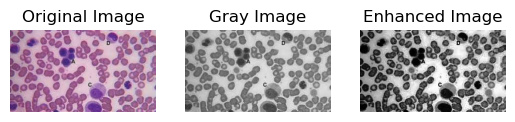

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(r"C:\Users\soura\Documents\Sem 6 Labs\IPMV\Images\blood_cells.jfif")
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

img2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.subplot(1,3,2)
plt.imshow(img2, cmap='gray')
plt.title("Gray Image")
plt.axis('off')

enhanced = cv2.equalizeHist(img2)
plt.subplot(1,3,3)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced Image")
plt.axis('off')


(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

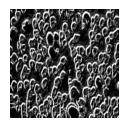

In [12]:
#PREWITT EDGE DETECTION

kernelx= np.array([[1,0,-1],
                   [1,0,-1],
                   [1,0,-1]])

kernely = np.array([[1,1,1],
                   [0,0,0],
                   [-1,-1,-1]])

prewitt_x = cv2.filter2D(enhanced, -1, kernelx)
prewitt_y = cv2.filter2D(enhanced, -1, kernely)

prewitt = cv2.add(prewitt_x, prewitt_y)
prewitt = cv2.resize(prewitt,(600,600))

plt.subplot(3,3,1)
plt.imshow(prewitt, cmap='gray')
plt.axis('off')                   

(np.float64(-0.5), np.float64(298.5), np.float64(167.5), np.float64(-0.5))

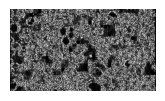

In [16]:
#Sobel

sobelx = cv2.Sobel(enhanced, cv2.CV_64F, 1,0, ksize=3)
sobely= cv2.Sobel(enhanced, cv2.CV_64F, 1,0, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = np.uint8(sobel)
plt.subplot(3,3,2)
plt.imshow(sobel, cmap='gray')
plt.axis('off') 

(np.float64(-0.5), np.float64(298.5), np.float64(167.5), np.float64(-0.5))

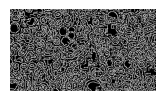

In [17]:
#Canny

canny = cv2.Canny(enhanced, 0, 50)
plt.subplot(3,3,2)
plt.imshow(canny, cmap='gray')
plt.axis('off') 

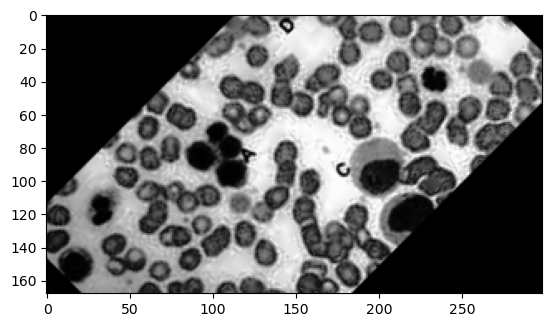

In [19]:
(h,w) = enhanced.shape
center= (w//2, h//2)

M = cv2.getRotationMatrix2D(center, 45,1.0)
rotated = cv2.warpAffine(enhanced,M, (w,h))
plt.imshow(rotated, cmap='gray')